## Решение задачи множественной классификации

In [27]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

### EDA

In [2]:
data = pd.read_csv('../data/smartphone_dependence.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

<font size=3\>
Датасет содержит следующие поля:

  - `transaction_id` — уникальный идентификатор транзакции/записи
  - `user_id` — уникальный идентификатор пользователя
  - `age` — возраст пользователя
  - `gender` — пол пользователя
  - `daily_screen_time_hours` — общее ежедневное время использования смартфона (в часах)
  - `social_media_hours` — время, проводимое в социальных сетях (в часах)
  - `gaming_hours` — время, затрачиваемое на мобильные игры (в часах)
  - `work_study_hours` — время использования устройства для работы или учебы (в часах)
  - `sleep_hours` — средняя продолжительность сна пользователя (в часах)
  - `notifications_per_day` — количество уведомлений, получаемых за день
  - `app_opens_per_day` — количество открытий приложений в течение дня
  - `weekend_screen_time` — время использования смартфона в выходные дни (в часах)
  - `stress_level` — самооценка уровня стресса пользователя
  - `academic_work_impact` — влияние использования смартфона на академическую или рабочую продуктивность
  - `addiction_level` — категориальный уровень зависимости (None, Mild, Moderate, Severe)
  - `addicted_label` — бинарный признак наличия зависимости (0 или 1)

</font>

In [3]:
data.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [4]:
data = data.drop('transaction_id', axis=1)
data = data.drop('user_id', axis=1)
data = data.drop('addicted_label', axis=1) #

data.head(10)

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe
5,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe
6,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe
7,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate
8,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN
9,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe


In [5]:
(data.isna().sum() / data.shape[0] * 100).sort_values(ascending=False)

addiction_level            10.92
age                         0.00
gender                      0.00
daily_screen_time_hours     0.00
social_media_hours          0.00
gaming_hours                0.00
work_study_hours            0.00
sleep_hours                 0.00
notifications_per_day       0.00
app_opens_per_day           0.00
weekend_screen_time         0.00
stress_level                0.00
academic_work_impact        0.00
dtype: float64

In [6]:
data[data['addiction_level'].isna()]

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN
8,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN
11,27,Other,5.16,1.82,2.27,0.93,7.79,228,32,8.10,High,Yes,NaN
13,32,Male,4.09,1.74,1.35,3.74,5.54,76,16,4.77,High,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7447,20,Female,5.00,1.68,2.87,1.02,6.67,237,26,5.87,Medium,Yes,NaN
7454,29,Other,3.45,3.95,1.20,1.24,7.51,25,84,5.19,High,No,NaN
7457,29,Female,3.11,2.44,3.17,0.84,8.93,217,174,4.27,High,Yes,NaN
7481,29,Male,4.72,3.65,0.78,2.58,5.15,20,76,6.02,Medium,No,NaN


In [7]:
data['addiction_level'].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

In [8]:

data['addiction_level'] = data['addiction_level'].fillna('None')

print(f"Количество пропусков после заполнения: {data['addiction_level'].isna().sum()}")

data.head()

Количество пропусков после заполнения: 0


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe


In [9]:
print(data['gender'].value_counts())
print(data['stress_level'].value_counts())
print(data['academic_work_impact'].value_counts())
print(data['addiction_level'].value_counts())

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64
addiction_level
Moderate    2874
Severe      2434
Mild        1373
None         819
Name: count, dtype: int64


In [10]:
data = pd.get_dummies(data=data, columns=['gender'], drop_first=True, dtype=int)

stress_level_dict = {
    'Low': 0, 
    'Medium': 1,
    'High' : 2
}
data['stress_level'] = data['stress_level'].map(stress_level_dict)

academic_work_impact_dict = {
    'No': 0, 
    'Yes': 1,
}
data['academic_work_impact'] = data['academic_work_impact'].map(academic_work_impact_dict)

addiction_level_dict = {
    'None': 0, 
    'Mild': 1, 
    'Moderate': 2, 
    'Severe': 3
}
data['addiction_level'] = data['addiction_level'].map(addiction_level_dict)

data.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,gender_Male,gender_Other
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0,1,0
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0,0,1
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,1,0,1
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,2,0,1
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,3,1,0


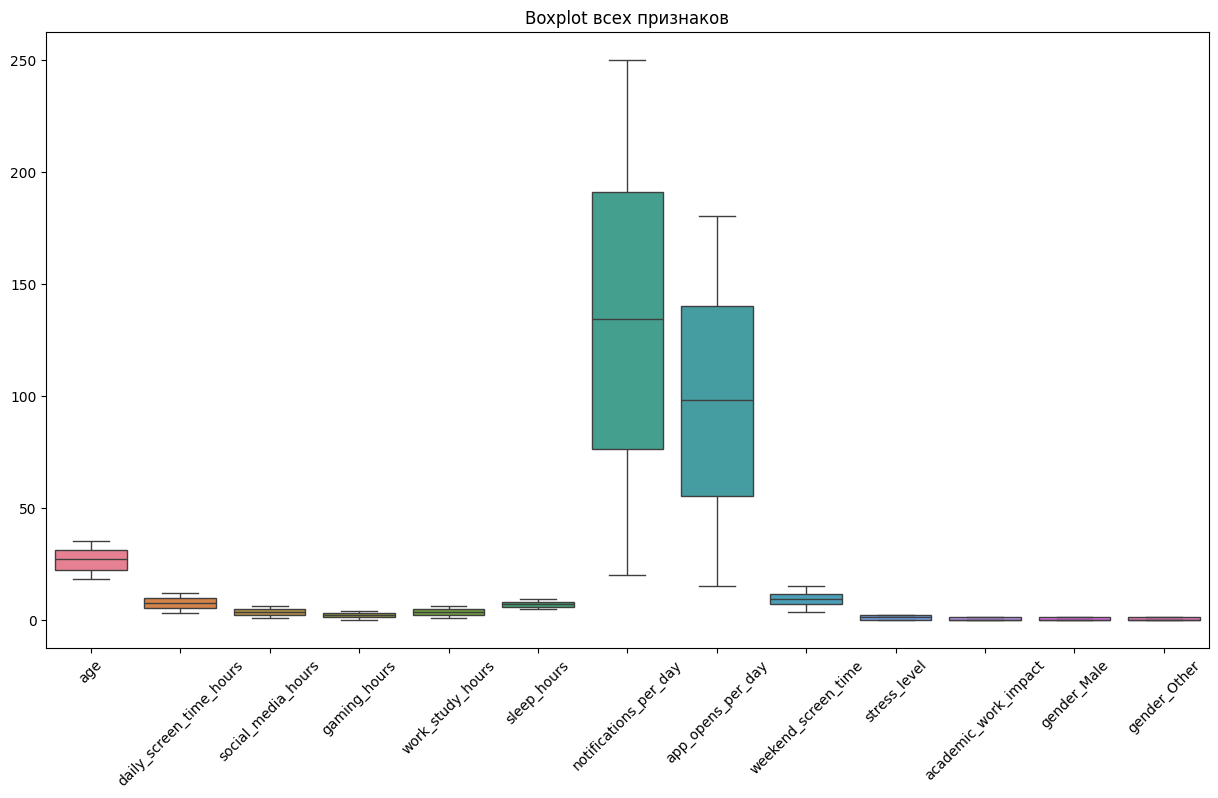

In [11]:
features = data.drop(['addiction_level'], axis=1, errors='ignore')

plt.figure(figsize=(15, 8))
sns.boxplot(data=features)
plt.xticks(rotation=45)
plt.title("Boxplot всех признаков")
plt.show()

### Выделение целевого признака и предиктора

In [12]:
y = data['addiction_level']
x = data.drop('addiction_level', axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, stratify=y)

### Масштабирование данных

In [13]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Логистическая регрессия

In [14]:
lr = LogisticRegression(
    penalty='elasticnet',
    multi_class='multinomial',
    solver='saga',
    l1_ratio=0.1
)

lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(x_test_scaled)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.48      0.32      0.39       164
           1       0.46      0.53      0.49       274
           2       0.48      0.65      0.55       575
           3       0.50      0.30      0.38       487

    accuracy                           0.48      1500
   macro avg       0.48      0.45      0.45      1500
weighted avg       0.48      0.48      0.47      1500

[[ 53  92  19   0]
 [ 51 144  78   1]
 [  4  52 373 146]
 [  3  23 313 148]]


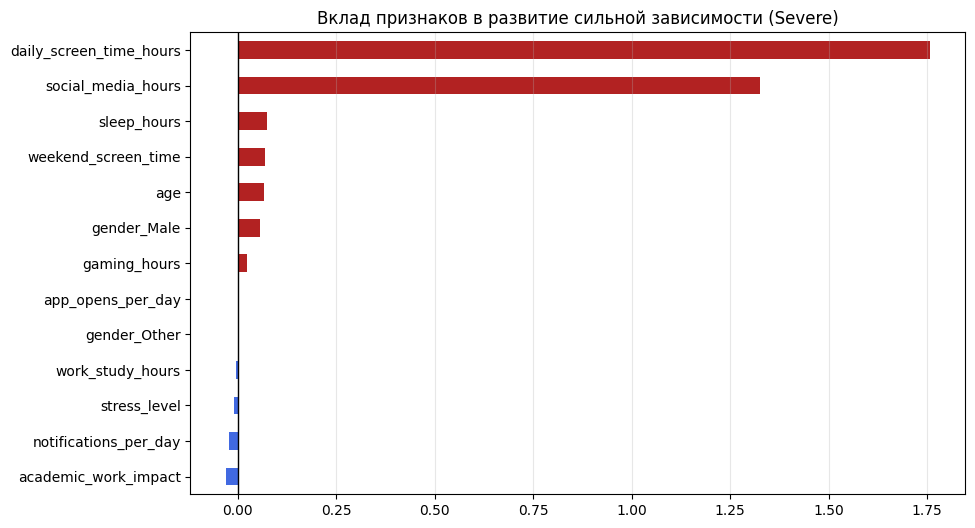

In [16]:
mapping = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}
actual_labels = [mapping[c] for c in lr.classes_]

coef_df = pd.DataFrame(
    lr.coef_, 
    columns=x.columns, 
    index=actual_labels
)

plt.figure(figsize=(10, 6))
severe_weights = coef_df.loc['Severe'].sort_values()

colors = ['firebrick' if x > 0 else 'royalblue' for x in severe_weights]
severe_weights.plot(kind='barh', color=colors)

plt.title('Вклад признаков в развитие сильной зависимости (Severe)')
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

* **Баланс метрик:** Наилучшую полноту (Recall = 0.65) модель показала для класса **Moderate**. Это значит, что большинство пользователей с умеренной зависимостью модель определяет успешно.

* **Матрица ошибок:** Видно, что модель часто путает класс `Severe` с `Moderate` (313 случаев), что говорит о близости этих групп в данных.

* **Лидеры влияния:** Самыми сильными предикторами сильной зависимости стали `daily_screen_time_hours` (коэффициент ~1.75) и `social_media_hours` (~1.3). Это подтверждает прямую связь между временем в соцсетях и риском зависимости.

* **Вторичные факторы:** Возраст (`age`), выходное время экрана (`weekend_screen_time`) и мужской пол (`gender_Male`) также вносят положительный, но менее значимый вклад.

* **Защитные факторы:** Единственные факторы, которые статистически снижают риск зависимости в этой модели — это `academic_work_impact` и `notifications_per_day`.

### Деревья классификации (CART)

In [21]:
def objective(trial):
    params = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'splitter': trial.suggest_categorical('splitter', ['best', 'random']),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        DecisionTreeClassifier(**params), x_train_scaled, y_train, cv=kf,
        scoring='f1_weighted',
        n_jobs=-1
    )

    return score.mean()

In [22]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=-1)

[I 2026-04-14 21:25:40,172] A new study created in memory with name: no-name-106df1ba-2174-49dd-a2c0-bd6ffa401f05
[I 2026-04-14 21:25:41,938] Trial 3 finished with value: 0.3943279569088035 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 4, 'min_samples_split': 28, 'min_samples_leaf': 8, 'max_leaf_nodes': 23, 'min_impurity_decrease': 0.056378577502926755, 'ccp_alpha': 0.0013677266359107376}. Best is trial 3 with value: 0.3943279569088035.
[I 2026-04-14 21:25:41,991] Trial 5 finished with value: 0.3943279569088035 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 8, 'min_samples_split': 28, 'min_samples_leaf': 14, 'max_leaf_nodes': 22, 'min_impurity_decrease': 0.08653687514457004, 'ccp_alpha': 0.008475098902612438}. Best is trial 3 with value: 0.3943279569088035.
[I 2026-04-14 21:25:42,076] Trial 6 finished with value: 0.41939099712961136 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 10, 'min_samples_split': 

In [23]:
best_model = DecisionTreeClassifier(**study.best_params, random_state=81)
best_model.fit(x_train_scaled, y_train)

y_pred = best_model.predict(x_test_scaled)
y_proba = best_model.predict_proba(x_test_scaled)

In [25]:
metrics = {
    "Model": 'DTC Optimized',
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred, average='weighted'), 4),
    "Recall": round(recall_score(y_test, y_pred, average='weighted'), 4),
    "F1-Score": round(f1_score(y_test, y_pred, average='weighted'), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'), 4)
}
res = pd.DataFrame([metrics])

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.66       164
           1       0.56      0.39      0.46       274
           2       0.56      0.09      0.16       575
           3       0.50      0.91      0.65       487

    accuracy                           0.51      1500
   macro avg       0.53      0.60      0.48      1500
weighted avg       0.53      0.51      0.43      1500



In [26]:
res

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,DTC Optimized,0.5127,0.5332,0.5127,0.4288,0.7788


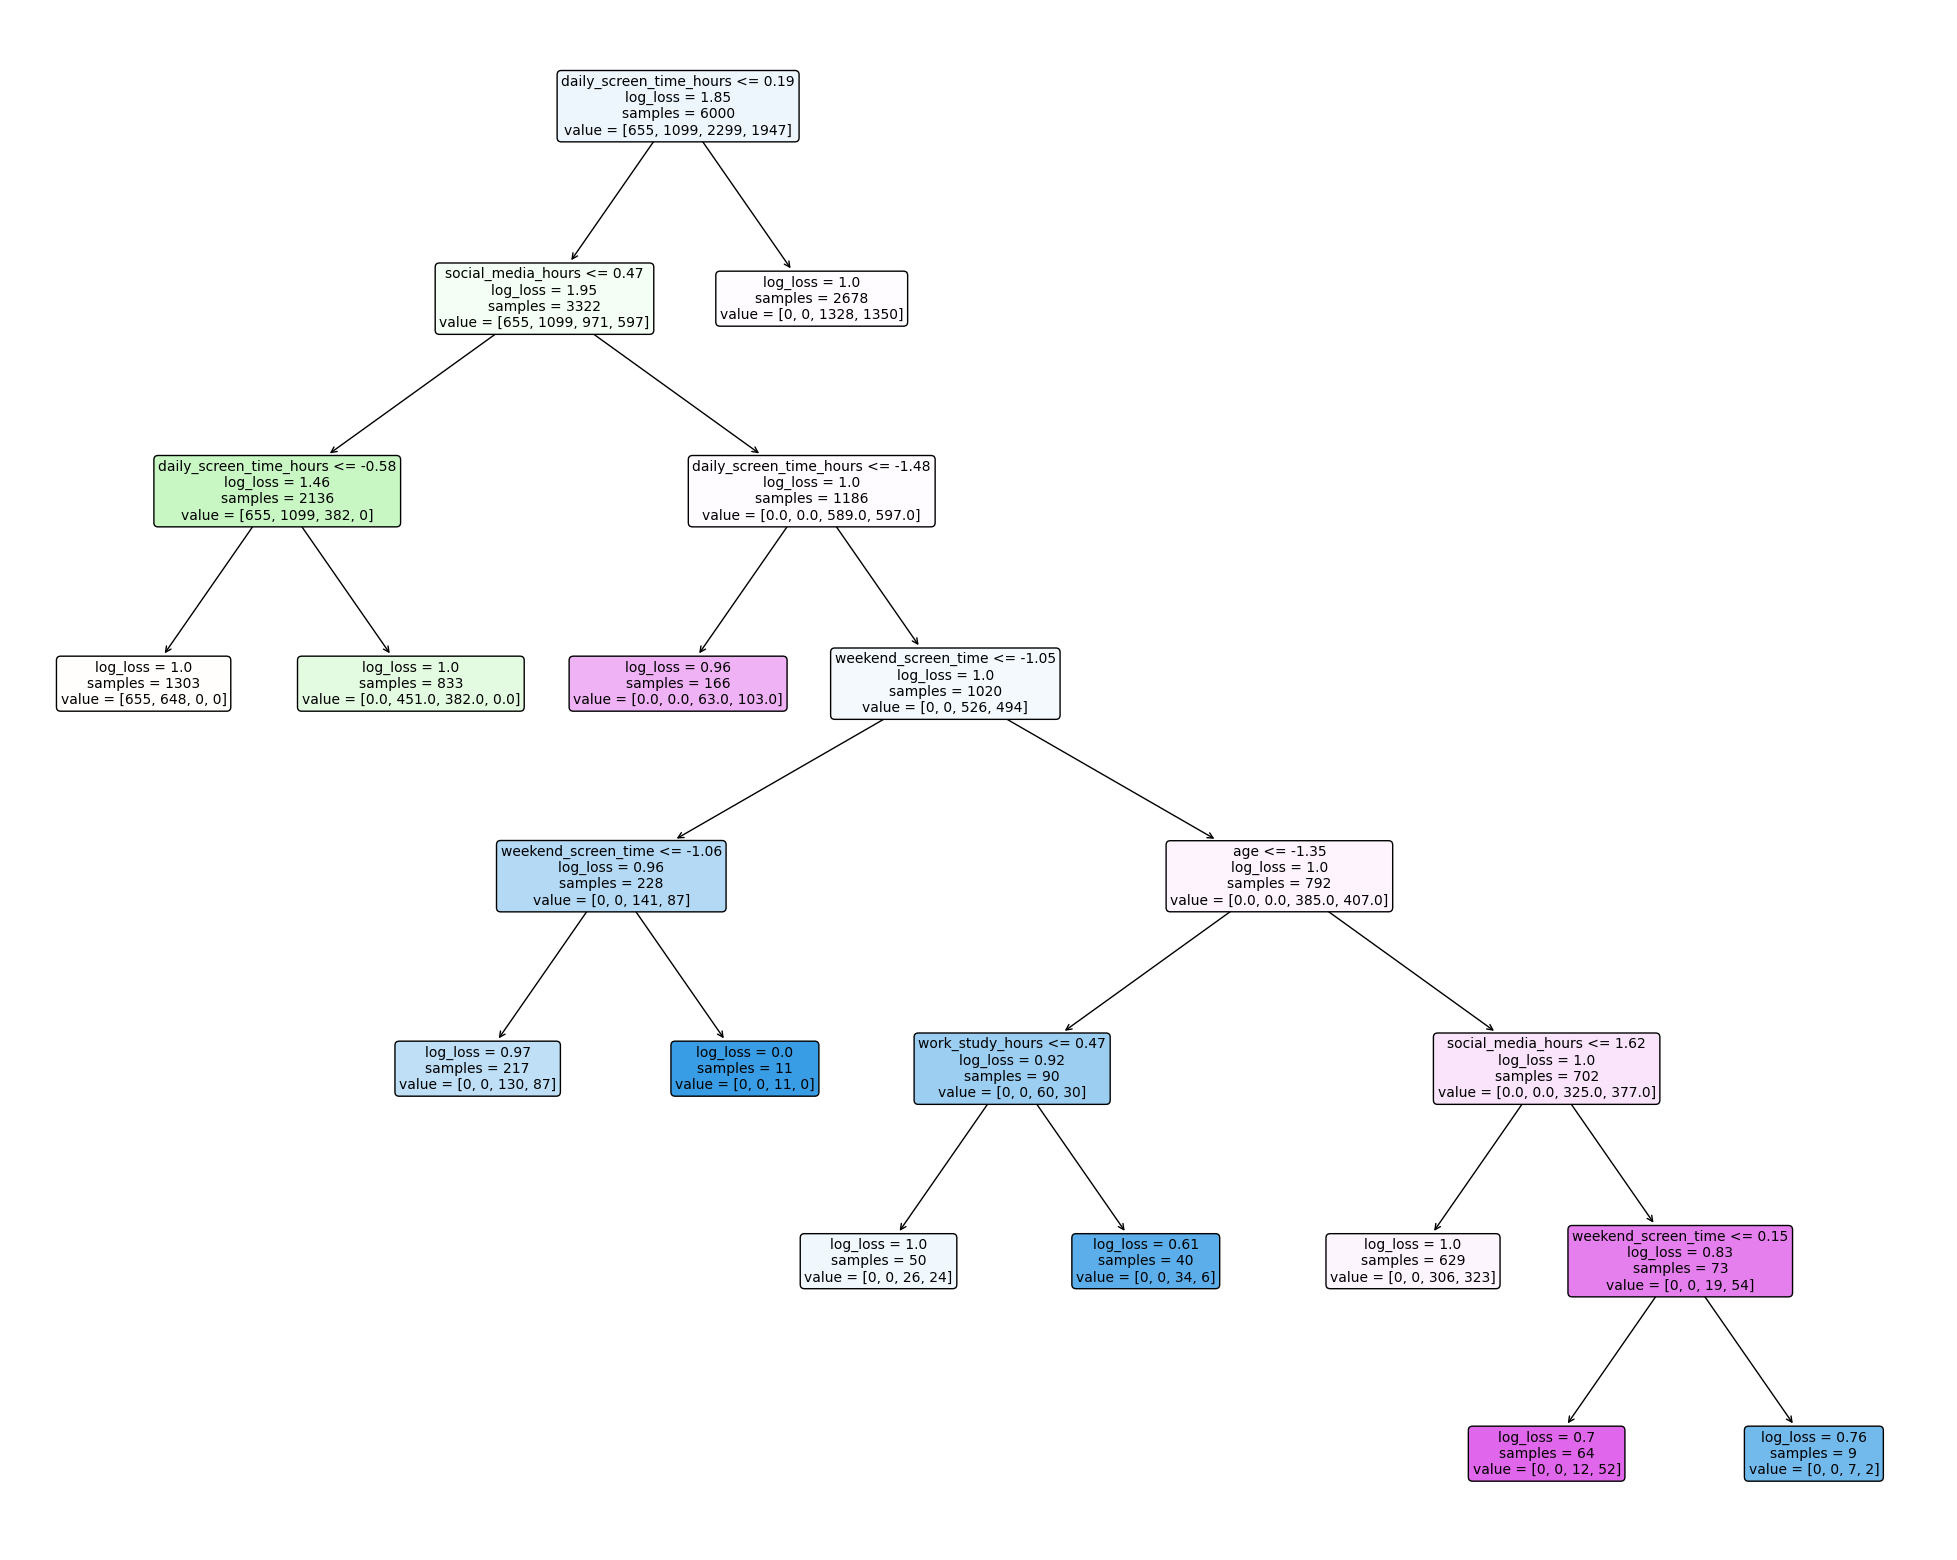

In [28]:
fig = plt.figure(figsize=(25, 20), facecolor='white')
ax = fig.add_subplot(111)

plot_tree(best_model, 
          feature_names=list(x.columns), 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=10,
          ax=ax)

plt.show()

##### Иерархические взаимодействия
Оптимизированное дерево решений (DTC Optimized) позволило выявить четкую иерархию признаков, влияющих на уровень зависимости:
* **Корневой узел:** Главным разделителем является `daily_screen_time_hours`. Это подтверждает, что общее время использования смартфона — первичный фактор сегментации пользователей.
* **Вторичные уровни:** Сразу за временем экрана следует `social_media_hours`. Интересно, что дерево разделяет выборку по социальным сетям только при определенных значениях общего экранного времени, что демонстрирует вложенную структуру данных.
* **Глубокие связи:** На нижних уровнях дерева в игру вступают `weekend_screen_time`, `age` и `work_study_hours`. Это позволяет выделить узкие группы риска (например, молодые пользователи с высокой активностью в выходные).

##### Обнаружение нелинейных эффектов
В отличие от логистической регрессии, дерево CART зафиксировало нелинейные паттерны:
* **Пороговые значения:** Модель выявила конкретные "точки перелома" (например, `daily_screen_time_hours <= 0.19` в нормализованных величинах), после которых вероятность перехода в более тяжелый класс зависимости резко возрастает. В регрессии такое влияние считалось бы линейным и равномерным.
* **Сложные условия:** Мы видим, что влияние возраста (`age`) проявляется только в глубоких ветвях дерева, когда другие поведенческие факторы уже зафиксированы. Это доказывает, что возраст сам по себе не является прямой причиной зависимости, но выступает модификатором поведения.

##### Оценка предсказательной способности
* **Точность:** Оптимизированное дерево показало **Accuracy = 0.5127**, что несколько выше результата логистической регрессии без лейбла (~0.48).
* **Качество классификации:** Высокое значение **ROC-AUC (0.7788)** говорит о хорошей способности модели разделять классы между собой.
* **Анализ классов:** Модель идеально справилась с поиском класса 0 (Recall = 1.00) и отлично находит класс 3 (Recall = 0.91), но испытывает серьезные трудности с классом 2 (Recall = 0.09). Это важный инсайт: промежуточные уровни зависимости в данных сильно перемешаны, в то время как экстремальные состояния (отсутствие и сильная зависимость) диагностируются моделью очень четко.